# 🌐 OpenCV 360° Panorama Stitcher — AdvancedStitcher Class

## 📌 What does this notebook do?
This notebook stitches **multiple overlapping photos** into a **360° panorama image**
using OpenCV's powerful built-in `cv2.Stitcher` with an object-oriented `AdvancedStitcher` class.

It is cleaner and more flexible than a procedural script because:
- All settings and images are bundled inside the class object
- You can easily reuse it for multiple folders / stitching modes
- Error handling and preprocessing are separated into clean methods

---

## 📁 Files / Images Required

| Requirement | Details |
|---|---|
| **Input folder** | A folder named `data` in the **same directory as this notebook** |
| **Image formats** | `.jpg`, `.jpeg`, `.png` |
| **Minimum images** | At least **2** (ideally 10–30 overlapping shots) |
| **Overlap needed** | ~30–50% overlap between consecutive images |
| **Camera tip** | Rotate the camera horizontally from a **fixed point** (do not walk sideways) |

## 🗂️ Folder Structure
```
your_project/
│
├── OpenCv_stitch360_enhanced.ipynb   ← This notebook
│
└── data/                              ← Put ALL your images here
    ├── 1.jpeg
    ├── 2.jpeg
    └── 3.jpeg
```

## 🚀 Output
- **`stitched_output.jpg`** saved in the same folder as this notebook

---

## ⚙️ Step 0 — Install Required Libraries (Run Once)
Run the cell below **only once** to install OpenCV.
After installation you can skip this cell on future runs.

In [1]:
# opencv-contrib-python includes OpenCV's extra modules.
# The Stitcher class and SIFT features are included in this package.
# --quiet suppresses verbose pip log output.
import sys
!{sys.executable} -m pip install opencv-contrib-python --quiet
print('✅ OpenCV ready.')

✅ OpenCV ready.


'C:\Users\vicky\Anaconda' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
# ============================================================
# CELL 1 — Import Libraries
# ============================================================

# cv2       : OpenCV — the core computer vision library.
#             We use it to: read images, resize them, and call the Stitcher.
import cv2

# glob      : Finds files matching a pattern (like *.jpg).
#             More flexible than os.listdir() for file discovery.
import glob

# numpy     : Numerical Python — images are stored as NumPy arrays.
#             Shape: (height, width, 3) for a colour image.
import numpy as np

# os        : Operating System utilities — used to check if paths exist,
#             list files, and build full file paths.
import os

# matplotlib: Used to display images INSIDE the Jupyter notebook.
#             NOTE: We do NOT use cv2.imshow() — it opens a separate window
#             which does not work well in Jupyter environments.
import matplotlib.pyplot as plt

print('✅ All libraries imported successfully.')
print(f'   OpenCV version : {cv2.__version__}')
print(f'   NumPy  version : {np.__version__}')


✅ All libraries imported successfully.
   OpenCV version : 4.12.0
   NumPy  version : 2.2.6


In [3]:
# ============================================================
# CELL 2 — Helper: Display an Image Inline in Jupyter
# ============================================================
# OpenCV loads images in BGR (Blue-Green-Red) colour order.
# Matplotlib expects RGB (Red-Green-Blue) colour order.
# Without conversion, red and blue channels will be swapped!

def show_image(img, title='Image', figsize=(16, 6)):
    """
    Display an OpenCV BGR image inline in Jupyter using matplotlib.

    Parameters:
        img     : NumPy array — BGR image from OpenCV
        title   : string      — title shown above the image
        figsize : tuple       — (width, height) in inches for the display
    """
    # cv2.COLOR_BGR2RGB : swaps the Blue and Red channels
    # This is required so matplotlib shows correct colours.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title, fontsize=14)
    plt.axis('off')      # Hide axis ticks for a clean image display
    plt.tight_layout()
    plt.show()

print('✅ Helper show_image() defined.')


✅ Helper show_image() defined.


In [4]:
# ============================================================
# CELL 3 — Define the AdvancedStitcher Class
# ============================================================
# A 'class' is a blueprint that bundles related data (attributes)
# and functions (methods) together.
#
# This class has TWO main responsibilities:
#   1. load_and_preprocess()  — load & optionally resize all images
#   2. stitch_advanced()      — stitch them into a panorama

class AdvancedStitcher:
    """
    A class to load, preprocess, and stitch images into a panorama.

    Internally uses cv2.Stitcher (OpenCV's automatic stitching engine)
    which performs:
      1. Feature Detection  — finds key-points in each image (SIFT)
      2. Feature Matching   — matches key-points across image pairs
      3. Bundle Adjustment  — globally optimises all camera angles
      4. Warping            — projects images onto a sphere or plane
      5. Blending           — seamlessly merges overlapping regions
    """

    # ------------------------------------------------------------------
    # __init__: The constructor — runs automatically when you write:
    #   my_stitcher = AdvancedStitcher('data')
    #
    # 'self' refers to the object being created.
    # 'folder' is the path to your images.
    # ------------------------------------------------------------------
    def __init__(self, folder):
        """
        Initialise the stitcher with a folder path.

        Parameters:
            folder : str — path to the folder containing images
                          (relative paths work fine in Jupyter)
        """
        # Store the folder path inside the object for later use
        self.folder = folder

        # Create an empty list to hold the loaded images.
        # After calling load_and_preprocess(), this will be filled
        # with NumPy arrays (one per image).
        self.images = []

    # ------------------------------------------------------------------
    # load_and_preprocess: Reads all valid images from self.folder,
    # optionally scales them, and stores them in self.images.
    # ------------------------------------------------------------------
    def load_and_preprocess(self, scale=1.0):
        """
        Loads all .jpg / .jpeg / .png images from the folder.
        Optionally resizes them using a scale factor.

        Parameters:
            scale : float — resize factor applied to width AND height.
                    scale=1.0 → no resize (original size)
                    scale=0.5 → half size in each dimension (4× fewer pixels)
                    scale=0.2 → 1/5 of original size (100× fewer pixels)
                    ⚠️ Smaller images = faster stitching BUT lower quality.
                    Recommended: 0.3–0.7 for a good speed/quality balance.
        """
        print(f'[INFO] Loading images from: {os.path.abspath(self.folder)}')

        # ── Step 1: Find all image files using glob ────────────────────
        # glob.glob() returns a list of file paths matching a pattern.
        # os.path.join builds a proper path, e.g. 'data/*'
        # We match ALL files ('*') then filter by extension below.
        image_paths = glob.glob(os.path.join(self.folder, '*'))

        # Filter: keep only image files (case-insensitive extension check)
        # .lower() converts '.JPG' → '.jpg' so uppercase extensions work too
        image_paths = [
            p for p in image_paths
            if p.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        print(f'[DEBUG] Found {len(image_paths)} candidate image file(s).')

        # Guard: stop early if no images are found
        if not image_paths:
            print('[ERROR] No image files found in the folder!')
            print(f'        Check that "{self.folder}" exists and contains images.')
            return

        loaded = 0   # Counter for successfully loaded images

        # ── Step 2: Load and optionally resize each image ─────────────
        # sorted() ensures a consistent order (e.g., 1.jpg before 10.jpg)
        for path in sorted(image_paths):

            # cv2.imread() reads the image file as a BGR NumPy array.
            # Returns None if the file is corrupt or unreadable.
            img = cv2.imread(path)

            if img is None:
                print(f'[WARNING] Failed to load: {path} — skipping.')
                continue

            # ── Optional: Resize the image ────────────────────────────
            # We only resize if scale != 1.0 to avoid unnecessary work.
            # cv2.resize with fx/fy scales width and height independently.
            #   fx=scale → scale the width
            #   fy=scale → scale the height
            # dsize=None means "compute size from fx/fy" (required when using fx/fy)
            if scale != 1.0:
                img = cv2.resize(img, None, fx=scale, fy=scale)

            # Append the (possibly resized) image to our list
            self.images.append(img)
            loaded += 1

            # Print: filename + resulting image shape (height, width, channels)
            filename = os.path.basename(path)
            print(f'   ✅ Loaded: {filename:20s}  →  shape {img.shape}')

        print(f'\n[INFO] Successfully loaded {loaded} image(s).')

    # ------------------------------------------------------------------
    # stitch_advanced: Calls OpenCV's built-in Stitcher to create
    # a panorama from self.images.
    # ------------------------------------------------------------------
    def stitch_advanced(self, mode='PANORAMA'):
        """
        Stitches self.images into a panorama using cv2.Stitcher.

        Parameters:
            mode : str — stitching projection mode:
                'PANORAMA' → spherical projection (best for 360° shots
                              taken by rotating a camera in place)
                'SCANS'    → flat/affine projection (best for document
                              scans placed side by side on a flat surface)

        Returns:
            stitched : NumPy array (BGR) — the final panorama image
                       OR None if stitching failed
        """

        # Guard: need at least 2 images to stitch
        if len(self.images) < 2:
            print('[ERROR] Need at least 2 images to stitch.')
            print(f'        Currently loaded: {len(self.images)} image(s).')
            print('        Call load_and_preprocess() first.')
            return None

        print(f'[INFO] Starting stitching with mode="{mode}"...')
        print(f'       Images to stitch: {len(self.images)}')
        print('       (This may take 1–5 minutes depending on image count and size.)')

        # ── Create the OpenCV Stitcher ─────────────────────────────────
        # cv2.Stitcher_PANORAMA → spherical warp (best for 360° panoramas)
        # cv2.Stitcher_SCANS    → flat affine warp (best for document scans)
        if mode == 'PANORAMA':
            stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
        else:
            stitcher = cv2.Stitcher_create(cv2.Stitcher_SCANS)

        # ── Run the stitching ──────────────────────────────────────────
        # stitcher.stitch() returns a tuple:
        #   status   : int  — 0 = OK, 1/2/3 = different errors (see below)
        #   stitched : NumPy array — the result (only valid if status == 0)
        status, stitched = stitcher.stitch(self.images)

        # ── Check the result ───────────────────────────────────────────
        if status != cv2.Stitcher_OK:
            # Map status code to a helpful error message
            error_map = {
                1: 'ERR_NEED_MORE_IMGS — Not enough overlapping images.\n'
                   '   💡 Fix: Use more images; ensure 30–50% overlap between shots.',
                2: 'ERR_HOMOGRAPHY_EST_FAIL — Could not match features.\n'
                   '   💡 Fix: Images may be too dark, blurry, or featureless.',
                3: 'ERR_CAMERA_PARAMS_ADJUST_FAIL — Camera geometry mismatch.\n'
                   '   💡 Fix: Use images from the same camera; rotate in place.',
            }
            print(f'\n[ERROR] Stitching failed. Status code: {status}')
            print('        Reason:', error_map.get(status, f'Unknown error: {status}'))
            return None

        print('\n[INFO] ✨ Stitching successful!')
        print(f'       Result size: {stitched.shape[1]}W × {stitched.shape[0]}H pixels')
        return stitched


print("✅ Class 'AdvancedStitcher' defined.")
print('   Run the next cells to use it.')


✅ Class 'AdvancedStitcher' defined.
   Run the next cells to use it.


In [5]:
# ============================================================
# CELL 4 — Configuration & Folder Check
# ============================================================
# Set your input folder path here.
# Using a relative path like 'data' means Jupyter will look
# for a folder named 'data' in the same directory as this notebook.

FOLDER_PATH = 'data'    # ← Change this if your images are in a different folder

# SCALE controls how much to resize images before stitching:
#   1.0 → original size (best quality, slowest)
#   0.5 → half size     (good quality, 4× faster)
#   0.2 → 20% size      (lower quality, 25× faster — good for testing)
SCALE = 0.5             # ← Adjust to trade off speed vs quality

# MODE controls the warping projection:
#   'PANORAMA' → spherical warp (best for 360° / rotating-camera shots)
#   'SCANS'    → affine warp    (best for flat document scans)
MODE = 'PANORAMA'       # ← Change to 'SCANS' if stitching scanned documents

# ── Sanity check: does the folder exist? ────────────────────────────────────
abs_path = os.path.abspath(FOLDER_PATH)
print(f'[CHECK] Folder path : {abs_path}')

if os.path.exists(FOLDER_PATH):
    files = os.listdir(FOLDER_PATH)
    img_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f'[CHECK] Folder exists  : ✅ Yes')
    print(f'[CHECK] Total files    : {len(files)}')
    print(f'[CHECK] Image files    : {len(img_files)}')
    if img_files:
        print('[CHECK] Image filenames:')
        for f in sorted(img_files):
            print(f'        - {f}')
else:
    print(f'[CHECK] Folder exists  : ❌ NOT FOUND')
    print(f'        Please create the folder and add your images.')
    print(f'        Expected location: {abs_path}')


[CHECK] Folder path : C:\Users\vicky\Desktop\CV\CV29\data
[CHECK] Folder exists  : ✅ Yes
[CHECK] Total files    : 30
[CHECK] Image files    : 30
[CHECK] Image filenames:
        - 1.jpeg
        - 10.jpeg
        - 11.jpeg
        - 12.jpeg
        - 13.jpeg
        - 14.jpeg
        - 15.jpeg
        - 16.jpeg
        - 17.jpeg
        - 18.jpeg
        - 19.jpeg
        - 2.jpeg
        - 20.jpeg
        - 21.jpeg
        - 22.jpeg
        - 23.jpeg
        - 24.jpeg
        - 25.jpeg
        - 26.jpeg
        - 27.jpeg
        - 28.jpeg
        - 29.jpeg
        - 3.jpeg
        - 30.jpeg
        - 4.jpeg
        - 5.jpeg
        - 6.jpeg
        - 7.jpeg
        - 8.jpeg
        - 9.jpeg


In [6]:
# ============================================================
# CELL 5 — Create the Stitcher Object & Load Images
# ============================================================
# Step 1: Create an AdvancedStitcher object.
#   This runs __init__() which sets self.folder and self.images = [].
my_stitcher = AdvancedStitcher(FOLDER_PATH)

# Step 2: Load and preprocess the images.
#   This fills my_stitcher.images with NumPy arrays.
#   scale=SCALE resizes each image proportionally.
my_stitcher.load_and_preprocess(scale=SCALE)

# Guard: confirm we loaded enough images before continuing
print(f'\n📦 Total images ready for stitching: {len(my_stitcher.images)}')
if len(my_stitcher.images) < 2:
    print('⚠️  Please add more images to the folder and re-run this cell.')


[INFO] Loading images from: C:\Users\vicky\Desktop\CV\CV29\data
[DEBUG] Found 30 candidate image file(s).
   ✅ Loaded: 1.jpeg                →  shape (450, 800, 3)
   ✅ Loaded: 10.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 11.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 12.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 13.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 14.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 15.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 16.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 17.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 18.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 19.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 2.jpeg                →  shape (450, 800, 3)
   ✅ Loaded: 20.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 21.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 22.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 23.jpeg    

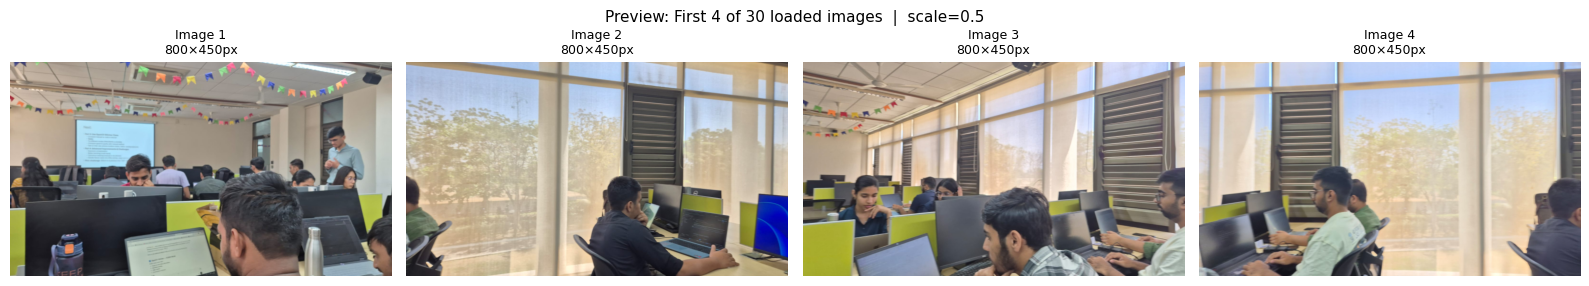

👆 Verify these are your images in the correct order, then run the next cell.


In [7]:
# ============================================================
# CELL 6 — (Optional) Preview the First 4 Loaded Images
# ============================================================
# Before stitching, visually verify that:
#   - The correct images were loaded
#   - They are in the right left-to-right order
#   - There is visible overlap between adjacent images
#
# We show at most 4 images as a quick check.

if my_stitcher.images:
    preview = my_stitcher.images[:4]   # Grab up to 4 images
    n = len(preview)

    fig, axes = plt.subplots(1, n, figsize=(n * 4, 3))

    # If only 1 image, axes is a single object — wrap it in a list
    if n == 1:
        axes = [axes]

    for i, img in enumerate(preview):
        # Convert BGR → RGB before passing to Matplotlib
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f'Image {i+1}\n{img.shape[1]}×{img.shape[0]}px', fontsize=9)
        axes[i].axis('off')   # Hide axis ticks

    plt.suptitle(
        f'Preview: First {n} of {len(my_stitcher.images)} loaded images  |  scale={SCALE}',
        fontsize=11
    )
    plt.tight_layout()
    plt.show()
    print('👆 Verify these are your images in the correct order, then run the next cell.')
else:
    print('⚠️  No images loaded — check FOLDER_PATH and re-run Cell 5.')


  Stitching 30 images in "PANORAMA" mode...
[INFO] Starting stitching with mode="PANORAMA"...
       Images to stitch: 30
       (This may take 1–5 minutes depending on image count and size.)

[INFO] ✨ Stitching successful!
       Result size: 3673W × 460H pixels

💾 Saved as: C:\Users\vicky\Desktop\CV\CV29\stitched_output.jpg


C:\Users\vicky\AppData\Local\Temp\ipykernel_20224\1427292698.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vicky\Anaconda 2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


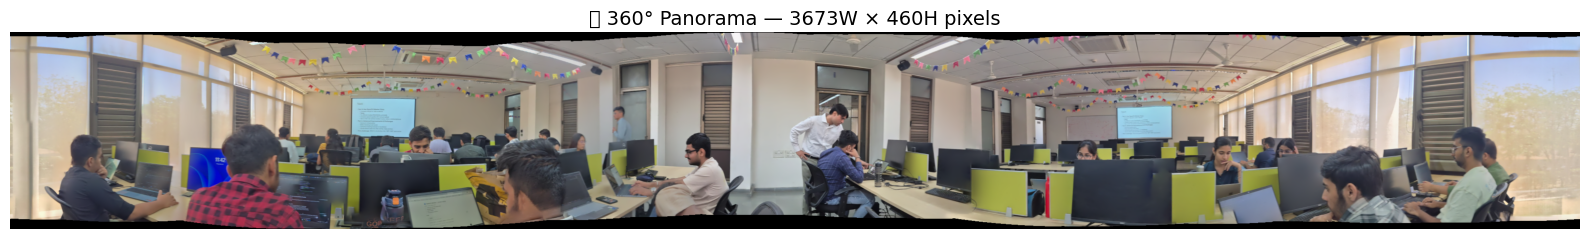

In [8]:
# ============================================================
# CELL 7 — Run Stitching & Display Result
# ============================================================
# stitch_advanced() calls OpenCV's Stitcher which internally:
#   1. Detects key-points (SIFT features) in every image
#   2. Matches key-points across all image pairs
#   3. Runs Bundle Adjustment to globally optimise camera angles
#   4. Warps each image onto a shared spherical/planar canvas
#   5. Blends the seams between images smoothly

print('=' * 60)
print(f'  Stitching {len(my_stitcher.images)} images in "{MODE}" mode...')
print('=' * 60)

result = my_stitcher.stitch_advanced(mode=MODE)

# ── If stitching succeeded, display and save the result ────────────────────
if result is not None:

    # Save the panorama to disk as a JPEG file
    output_path = 'stitched_output.jpg'
    cv2.imwrite(output_path, result)
    print(f'\n💾 Saved as: {os.path.abspath(output_path)}')

    # Display the panorama inline in Jupyter
    # show_image() handles the BGR → RGB conversion for Matplotlib
    show_image(
        result,
        title=f'✅ 360° Panorama — {result.shape[1]}W × {result.shape[0]}H pixels'
    )

else:
    print('\n❌ Stitching failed. See error message above for tips.')
    print('   Common fixes:')
    print('   1. Increase overlap between images (aim for 30–50%)')
    print('   2. Use sharper / better-lit images')
    print('   3. Try a larger scale (e.g., SCALE=0.5 instead of 0.2)')
    print('   4. Make sure all images come from the same camera')


  Trying alternative mode: SCANS...
[INFO] Loading images from: C:\Users\vicky\Desktop\CV\CV29\data
[DEBUG] Found 30 candidate image file(s).
   ✅ Loaded: 1.jpeg                →  shape (450, 800, 3)
   ✅ Loaded: 10.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 11.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 12.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 13.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 14.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 15.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 16.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 17.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 18.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 19.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 2.jpeg                →  shape (450, 800, 3)
   ✅ Loaded: 20.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 21.jpeg               →  shape (450, 800, 3)
   ✅ Loaded: 22.jpeg               →  shape (4

C:\Users\vicky\AppData\Local\Temp\ipykernel_20224\1427292698.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


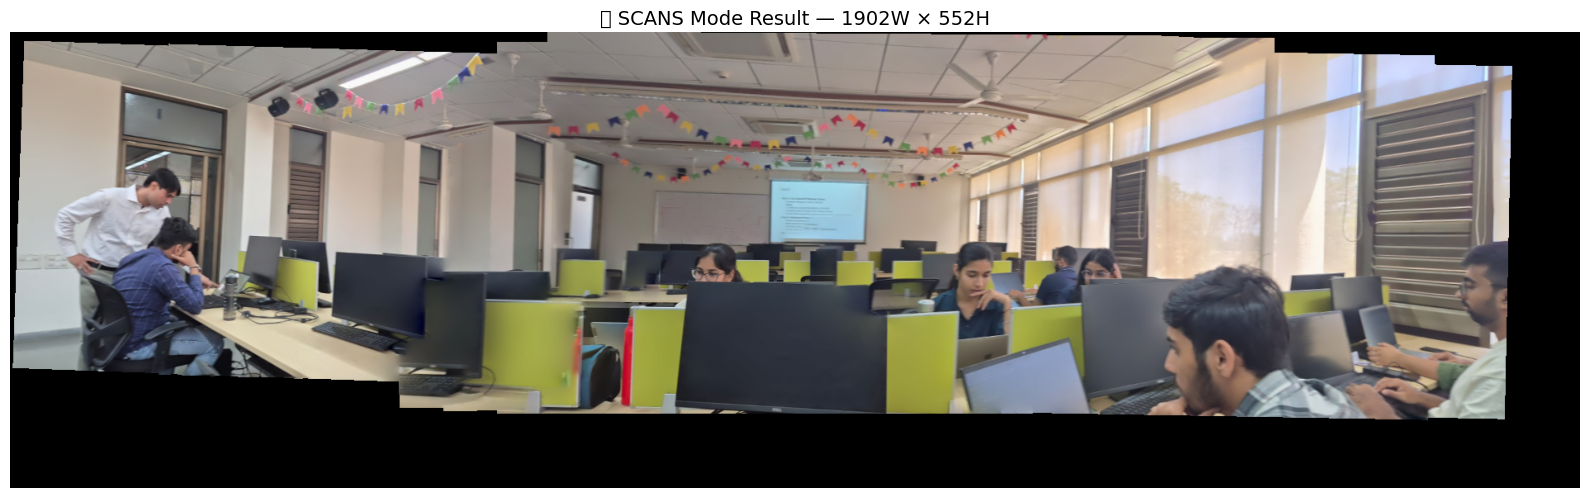

In [9]:
# ============================================================
# CELL 8 — (Optional) Try SCANS Mode
# ============================================================
# If PANORAMA mode fails, try SCANS mode.
# SCANS uses a flat (affine) projection instead of spherical.
# It works better when:
#   - Images are laid side by side on a flat surface
#   - The camera moved sideways (translated) rather than rotated
#   - You are stitching scanned document pages

print('=' * 60)
print('  Trying alternative mode: SCANS...')
print('=' * 60)

# Create a fresh stitcher instance (self.images is re-loaded from scratch)
my_stitcher_scans = AdvancedStitcher(FOLDER_PATH)
my_stitcher_scans.load_and_preprocess(scale=SCALE)

result_scans = my_stitcher_scans.stitch_advanced(mode='SCANS')

if result_scans is not None:
    output_path_scans = 'stitched_output_scans.jpg'
    cv2.imwrite(output_path_scans, result_scans)
    print(f'\n💾 Saved as: {os.path.abspath(output_path_scans)}')
    show_image(
        result_scans,
        title=f'✅ SCANS Mode Result — {result_scans.shape[1]}W × {result_scans.shape[0]}H'
    )
else:
    print('\n❌ SCANS mode also failed. See tips in Cell 7.')


---
## 🛠️ Troubleshooting Guide

| Problem | Likely Cause | Solution |
|---|---|---|
| `ERR_NEED_MORE_IMGS` | Too few / non-overlapping images | Add more images; ensure 30–50% overlap |
| `ERR_HOMOGRAPHY_EST_FAIL` | Dark, blurry, or featureless photos | Use well-lit, sharp, textured scenes |
| `ERR_CAMERA_PARAMS_ADJUST_FAIL` | Mixed cameras or sideways movement | Rotate camera in place; don't walk sideways |
| Seam lines visible | Exposure differences between shots | Normalise brightness before shooting |
| Very slow | Images too large | Lower SCALE to 0.3 or 0.2 |
| Black borders | Normal after spherical warping | Result is still valid — crop manually if needed |
| `cv2` import error | OpenCV not installed | Run `pip install opencv-contrib-python` |
| Images in wrong order | Filenames not sortable numerically | Rename files: 01.jpg, 02.jpg, ... 30.jpg |

---
## 💡 Key Concepts Glossary

| Term | Plain English |
|---|---|
| **SIFT** | Finds 'interesting' corners/blobs in images — used for matching |
| **Key-point** | A distinctive pixel location (corner, edge) used to align images |
| **Bundle Adjustment** | Maths that simultaneously optimises all camera angles for best fit |
| **Spherical Warping** | Maps flat images onto a sphere — enables 360° panoramas |
| **Affine Warping** | Flat/parallel projection — used for side-by-side document scans |
| **BGR vs RGB** | OpenCV = Blue-Green-Red; Matplotlib = Red-Green-Blue |
| **scale** | A multiplier applied to image dimensions (0.5 = half width & height) |
| **glob** | A module that finds files matching wildcard patterns (like `*.jpg`) |
| **OOP / Class** | A way to group related data + functions into one reusable object |

---
## ⚡ Quick Settings Reference

| Setting | Recommended Value | Effect |
|---|---|---|
| `SCALE = 0.2` | Testing (fast) | Lowest quality, fastest run |
| `SCALE = 0.5` | General use | Good balance of speed & quality |
| `SCALE = 1.0` | Final output | Best quality, slowest |
| `MODE = 'PANORAMA'` | Rotating camera | 360° spherical panorama |
| `MODE = 'SCANS'` | Flat/translated images | Document / scan stitching |
